# Import Libraries



In [31]:
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load Data

In [ ]:
df = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

In [3]:
print("Data Loaded Successfully. Shape:", df.shape)

Data Loaded Successfully. Shape: (74836, 6)


In [4]:
print(f"🧹 Missing values before cleaning:\n{df.isnull().sum()}")
df.dropna(inplace=True)
df.sort_index(inplace=True)

🧹 Missing values before cleaning:
datetime    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64


# Data Exploration (EDA)


In [6]:
df.head()


,datetime,open,high,low,close,volume
0,2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009
1,2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916
2,2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691
3,2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249
4,2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74836 entries, 0 to 74835
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  74836 non-null  datetime64[us]
 1   open      74836 non-null  float64       
 2   high      74836 non-null  float64       
 3   low       74836 non-null  float64       
 4   close     74836 non-null  float64       
 5   volume    74836 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 3.4 MB


In [10]:
df.describe()


,datetime,open,high,low,close,volume
count,74836,74836.000000,74836.000000,74836.000000,74836.000000,74836.000000
mean,2021-11-27 13:49:54.307552,36851.016673,37001.564862,36692.820444,36851.874718,2574.760733
min,2017-08-17 04:00:00,2870.900000,2950.000000,2817.000000,2919.000000,0.000000
25%,2019-10-09 12:45:00,9211.495000,9246.992500,9174.075000,9211.905000,752.894197
50%,2021-11-28 12:30:00,26771.575000,26845.780000,26691.845000,26772.635000,1395.532382
75%,2024-01-17 02:15:00,57867.567500,58146.277500,57585.740000,57868.040000,2717.285290
max,2026-03-06 15:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600
std,NaN,32398.816181,32497.076909,32296.889244,32398.813822,3891.364361


# Feature Engineering

In [14]:
print("Engineering 15 Professional Features")

Engineering 15 Professional Features


### EMA

In [15]:
df['EMA_10'] = df['close'].ewm(span=10, adjust=False).mean()
df['EMA_20'] = df['close'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['close'].ewm(span=50, adjust=False).mean()

## Momentum Indicators

### 1. RSI (14)

In [16]:
delta = df['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df['RSI'] = 100 - (100 / (1 + (gain / loss)))

### 2. MACD (12, 26, 9)

In [17]:
exp12 = df['close'].ewm(span=12, adjust=False).mean()
exp26 = df['close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp12 - exp26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

### 3. Stochastic %K (14)

In [18]:
low_14 = df['low'].rolling(window=14).min()
high_14 = df['high'].rolling(window=14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14))
df['Will_R'] = -100 * ((high_14 - df['close']) / (high_14 - low_14))

##  Volatility Indicators

### 1. ATR (Average True Range)

In [19]:
high_low = df['high'] - df['low']
high_pc = np.abs(df['high'] - df['close'].shift())
low_pc = np.abs(df['low'] - df['close'].shift())
tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
df['ATR'] = tr.rolling(window=14).mean()

### 2. Bollinger Bands (20, 2) & BB Width

In [20]:
ma20 = df['close'].rolling(window=20).mean()
std20 = df['close'].rolling(window=20).std()
df['BB_Width'] = (std20 * 4) / ma20

## Cycles & Strength 

### 1. CCI (20)

In [21]:
tp = (df['high'] + df['low'] + df['close']) / 3
ma_tp = tp.rolling(window=20).mean()
mad_tp = tp.rolling(window=20).apply(lambda x: np.abs(x - x.mean()).mean())
df['CCI'] = (tp - ma_tp) / (0.015 * mad_tp)

## Returns

In [46]:
cols_to_pct = ['open', 'high', 'low', 'close', 'volume', 'EMA_10', 'EMA_20', 'EMA_50', 'ATR']
for col in cols_to_pct:
    df[col + '_ret'] = df[col].pct_change()

KeyError: 'open'

## Target

In [23]:
df['Target'] = (df['close'].shift(-24) > df['close']).astype(int)

In [24]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

### test

In [25]:
df.describe()


,datetime,open,high,low,close,volume,EMA_10,EMA_20,EMA_50,RSI,...,open_ret,high_ret,low_ret,close_ret,volume_ret,EMA_10_ret,EMA_20_ret,EMA_50_ret,ATR_ret,Target
count,74813,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,...,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000
mean,2021-11-28 00:04:54.205552,36860.099926,37010.676729,36701.869749,36860.956164,2575.379854,36857.019995,36852.571135,36839.213361,50.886943,...,0.000068,0.000060,0.000070,0.000067,0.155786,0.000040,0.000038,0.000038,0.002254,0.520284
min,2017-08-17 23:00:00,2870.900000,2950.000000,2817.000000,2919.000000,0.000000,3107.464635,3208.311460,3245.719244,0.547546,...,-0.182201,-0.129828,-0.243869,-0.182115,-1.000000,-0.047895,-0.030895,-0.015680,-0.450443,0.000000
25%,2019-10-10 04:00:00,9214.010000,9248.790000,9176.450000,9214.910000,753.337100,9211.639280,9209.998696,9214.189308,39.514754,...,-0.002473,-0.002261,-0.002067,-0.002480,-0.269560,-0.000733,-0.000551,-0.000384,-0.029974,0.000000
50%,2021-11-28 23:00:00,26779.450000,26848.070000,26702.630000,26779.790000,1395.793020,26801.605751,26795.211590,26778.609781,50.743969,...,0.000078,-0.000205,0.000352,0.000074,-0.033560,0.000060,0.000047,0.000038,-0.000472,1.000000
75%,2024-01-17 08:00:00,57877.970000,58150.000000,57599.570000,57877.970000,2717.847393,57831.722011,57854.979458,57773.696532,62.233130,...,0.002655,0.002067,0.002657,0.002672,0.310889,0.000867,0.000670,0.000493,0.028641,1.000000
max,2026-03-06 15:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,125062.361818,124694.100415,124031.476731,100.000000,...,0.173670,0.152525,0.271352,0.173840,190.760354,0.033865,0.020696,0.010494,1.701271,1.000000
std,NaN,32399.242186,32497.498599,32297.318552,32399.241479,3891.665299,32396.432938,32393.607577,32385.458176,16.425611,...,0.007824,0.006920,0.008053,0.007821,1.217032,0.002319,0.001629,0.001024,0.068748,0.499592


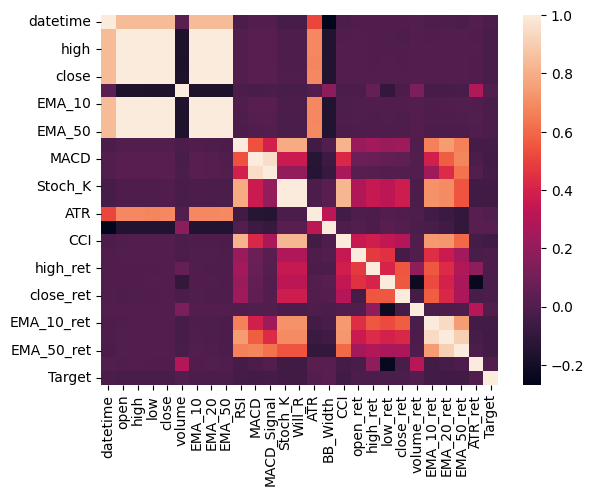

In [32]:
sns.heatmap(df.corr())
plt.show()
# !pip install seaborn

## remove the bad cloumne  

In [33]:
df = df.drop("open", axis=1)
df = df.drop("low", axis=1)
df = df.drop("high", axis=1)
df = df.drop("close", axis=1)
# df = df.drop("BB_Upper", axis=1)
df = df.drop("EMA_50", axis=1)
df = df.drop("EMA_10", axis=1)
df = df.drop("EMA_20", axis=1)


In [34]:
df = df.drop(["BB_Lower", "ATR"], axis=1, errors='ignore')

final_features = [
    'close_ret', 'volume_ret', 'open_ret', 'ATR_ret', 'EMA_10_ret',
    'RSI', 'MACD', 'MACD_Signal', 'Stoch_K', 'Will_R',
    'BB_Width', 'CCI', 'high_ret' 
]

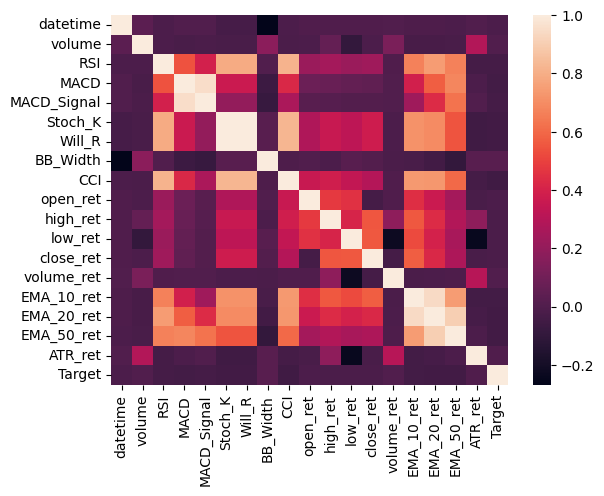

In [35]:
sns.heatmap(df.corr())
plt.show()

# Data Scaling

In [36]:
X_data = df[final_features].values
y_data = df['Target'].values

In [37]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)

In [38]:
joblib.dump(scaler, "egx360_scaler.pkl")
print("Data Scaled and Scaler saved.")

Data Scaled and Scaler saved.


# Train / Test Split

In [39]:
split_idx = int(len(X_scaled) * 0.8)

In [40]:
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]

In [41]:
print(f"📅 Training records: {len(train_data)} | Testing records: {len(test_data)}")

📅 Training records: 59850 | Testing records: 14963


# Create Sequences

In [42]:
def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 22

In [43]:
X_train, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test, y_test = create_sequences(test_data, test_target, SEQ_LEN)
print(f"📦 X_train shape: {X_train.shape}") # (Samples, Time Steps, Features)


📦 X_train shape: (59828, 22, 13)


# Build Model

In [44]:
def build_v1_pure(input_shape):
    inputs = Input(shape=input_shape)
    
    # طبقتين Bi-LSTM فقط لفهم الاتجاه
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Dropout(0.2)(x)
    x = Bidirectional(LSTM(32))(x)
    
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    return Model(inputs, outputs)

In [47]:
model = build_v1_pure((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

E0000 00:00:1772909599.666719   16814 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772909599.674515   16814 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# Train Model

In [48]:
print("⚖️ Calculating Class Weights...")
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: weights[i] for i in range(len(weights))}

⚖️ Calculating Class Weights...


NameError: name 'class_weight' is not defined

In [120]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
checkpoint = ModelCheckpoint("EGX360_Pro_Model.keras", monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.00001)

In [121]:
print("🚀 Starting Pro Training Process...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150, 
    batch_size=32,
    class_weight=cw_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

🚀 Starting Pro Training Process...
Epoch 1/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 92s 47ms/step - accuracy: 0.5188 - loss: 0.7018 - val_accuracy: 0.5120 - val_loss: 0.6997 - learning_rate: 1.0000e-04
Epoch 2/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.5276 - loss: 0.6942 - val_accuracy: 0.5004 - val_loss: 0.7045 - learning_rate: 1.0000e-04
Epoch 3/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.5398 - loss: 0.6889 - val_accuracy: 0.5154 - val_loss: 0.6942 - learning_rate: 1.0000e-04
Epoch 4/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.5514 - loss: 0.6834 - val_accuracy: 0.4905 - val_loss: 0.7072 - learning_rate: 1.0000e-04
Epoch 5/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.5576 - loss: 0.6804 - val_accuracy: 0.5168 - val_loss: 0.6989 - learning_rate: 1.0000e-04
Epoch 6/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.5693 - loss: 0.6747 - val_accuracy: 0.5053 - val_loss: 0.7134 - learning_rate: 1.0000e-04

KeyboardInterrupt: 

# Evaluate Model


📊 Evaluating Performance on Test Data...
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
✅ Optimal Threshold found: 0.10

🔥 Final Classification Report:
              precision    recall  f1-score   support

        Down       0.50      0.45      0.47      7297
          Up       0.52      0.58      0.55      7644

    accuracy                           0.51     14941
   macro avg       0.51      0.51      0.51     14941
weighted avg       0.51      0.51      0.51     14941



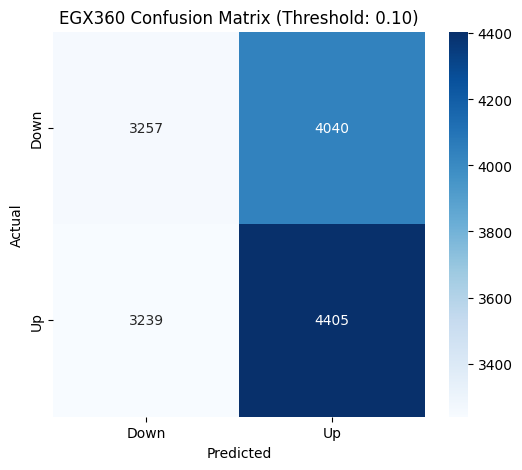

In [122]:
print("\n📊 Evaluating Performance on Test Data...")
y_probs = model.predict(X_test)

# Dynamic Thresholding for best F1-Score
thresholds = np.arange(0.1, 0.9, 0.01)
scores = [f1_score(y_test, (y_probs > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(scores)]
print(f'✅ Optimal Threshold found: {best_threshold:.2f}')

final_preds = (y_probs > 0.50).astype(int)

print("\n🔥 Final Classification Report:")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 Confusion Matrix (Threshold: {best_threshold:.2f})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [2]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, LSTM, Bidirectional, 
                                     Dense, Dropout, BatchNormalization, MultiHeadAttention, 
                                     GlobalAveragePooling1D, LayerNormalization, Add)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ==========================================
# 2. Load Data (Daily & Hourly)
# ==========================================
print("📥 Loading Data...")
# تأكد إن أسماء الملفات دي مطابقة للي عندك
df_daily = pd.read_csv("data/BTC_all_daily.csv")
df_daily['datetime'] = pd.to_datetime(df_daily['datetime'])
df_daily = df_daily.sort_values('datetime')

df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])
df_hourly = df_hourly.sort_values('datetime')

print(f"📊 Hourly Shape: {df_hourly.shape} | Daily Shape: {df_daily.shape}")

# ==========================================
# 3. Feature Engineering Function
# ==========================================
def calculate_features(df, prefix):
    print(f"⚙️ Engineering features for {prefix} data...")
    df = df.copy()
    
    # Trends
    df[f'EMA_10_{prefix}'] = df['close'].ewm(span=10, adjust=False).mean()
    
    # Momentum
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'RSI_{prefix}'] = 100 - (100 / (1 + (gain / loss)))
    
    exp12 = df['close'].ewm(span=12, adjust=False).mean()
    exp26 = df['close'].ewm(span=26, adjust=False).mean()
    df[f'MACD_{prefix}'] = exp12 - exp26
    
    # Volatility
    ma20 = df['close'].rolling(window=20).mean()
    std20 = df['close'].rolling(window=20).std()
    df[f'BB_Width_{prefix}'] = (std20 * 4) / ma20
    
    # Returns (Stationary Features)
    df[f'close_ret_{prefix}'] = df['close'].pct_change()
    df[f'volume_ret_{prefix}'] = df['volume'].pct_change()
    
    return df.dropna()

# تطبيق الحسابات
df_daily = calculate_features(df_daily, "daily")
df_hourly = calculate_features(df_hourly, "hourly")

# الاحتفاظ بالأعمدة المهمة من اليومي فقط
daily_features = ['datetime', 'RSI_daily', 'MACD_daily', 'BB_Width_daily', 'close_ret_daily']
df_daily = df_daily[daily_features]

# ==========================================
# 4. Data Fusion (Merge Hourly with Daily)
# ==========================================
print("🔗 Merging Hourly and Daily data (Data Fusion)...")
# دمج ذكي بيشوف أقرب يوم فات لكل ساعة
df_merged = pd.merge_asof(df_hourly, df_daily, on='datetime', direction='backward')

# Target: هل السعر بعد 24 ساعة هيكون أعلى؟
df_merged['Target'] = (df_merged['close'].shift(-24) > df_merged['close']).astype(int)

# 🔥 التعديل هنا: تحويل الـ Infinity لـ NaN عشان الـ dropna تقدر تمسحها
df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)
df_merged.dropna(inplace=True)

final_features = [
    'close_ret_hourly', 'volume_ret_hourly', 'EMA_10_hourly', 'RSI_hourly', 'MACD_hourly', 'BB_Width_hourly', 
    'close_ret_daily', 'RSI_daily', 'MACD_daily', 'BB_Width_daily' 
]

print(f"✅ Final Merged Data Shape: {df_merged.shape}")
# ==========================================
# 5. Data Scaling
# ==========================================
X_data = df_merged[final_features].values
y_data = df_merged['Target'].values

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)
joblib.dump(scaler, "egx360_scaler.pkl")
print("💾 Data Scaled and Scaler saved.")

# ==========================================
# 6. Train / Test Split
# ==========================================
split_idx = int(len(X_scaled) * 0.8)
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]
print(f"📅 Training records: {len(train_data)} | Testing records: {len(test_data)}")

# ==========================================
# 7. Create Sequences
# ==========================================
def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 72 # 3 أيام (72 ساعة) نظراً لأن الداتا بالساعة
X_train, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test, y_test = create_sequences(test_data, test_target, SEQ_LEN)
print(f"📦 X_train shape: {X_train.shape}") 

# ==========================================
# 8. Build Model
# ==========================================
def build_advanced_egx360(input_shape):
    inputs = Input(shape=input_shape)
    
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x) 
    
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = LayerNormalization()(x) 
    
    attention_out = MultiHeadAttention(num_heads=4, key_dim=128)(x, x)
    x = Add()([x, attention_out]) 
    
    x = GlobalAveragePooling1D()(x) 
    x = Dense(64, activation='swish')(x) 
    x = Dropout(0.4)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

model = build_advanced_egx360((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])
model.summary()

# ==========================================
# 9. Train Model
# ==========================================
print("⚖️ Calculating Class Weights...")
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: weights[i] for i in range(len(weights))}

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint("EGX360_Pro_Model.keras", monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.00001)

print("🚀 Starting Pro Training Process...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, 
    batch_size=32,
    class_weight=cw_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

# ==========================================
# 10. Evaluate Model
# ==========================================
print("\n📊 Evaluating Performance on Test Data...")
y_probs = model.predict(X_test)

# Dynamic Thresholding for best F1-Score
thresholds = np.arange(0.1, 0.9, 0.01)
scores = [f1_score(y_test, (y_probs > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(scores)]
print(f'✅ Optimal Threshold found: {best_threshold:.2f}')

# استخدام الـ Threshold المحسوب ديناميكياً
final_preds = (y_probs > best_threshold).astype(int)

print("\n🔥 Final Classification Report:")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 Confusion Matrix (Threshold: {best_threshold:.2f})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

📥 Loading Data...
📊 Hourly Shape: (74836, 6) | Daily Shape: (4189, 6)
⚙️ Engineering features for daily data...
⚙️ Engineering features for hourly data...
🔗 Merging Hourly and Daily data (Data Fusion)...
✅ Final Merged Data Shape: (74813, 17)
💾 Data Scaled and Scaler saved.
📅 Training records: 59850 | Testing records: 14963
📦 X_train shape: (59778, 72, 10)


E0000 00:00:1772817161.082350   46240 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772817161.088084   46240 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 72, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 72, 64)    │      1,984 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 72, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 36, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 36, 256)   │    197,632 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 36, 256)   │        512 │ bidirectional[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 256)   │    526,080 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 36, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ add[0][0]         │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 742,977 (2.83 MB)

 Trainable params: 742,849 (2.83 MB)

 Non-trainable params: 128 (512.00 B)

⚖️ Calculating Class Weights...
🚀 Starting Pro Training Process...
Epoch 1/100
1869/1869 ━━━━━━━━━━━━━━━━━━━━ 162s 85ms/step - accuracy: 0.6051 - loss: 0.6516 - val_accuracy: 0.5732 - val_loss: 0.6880 - learning_rate: 1.0000e-04
Epoch 2/100
1869/1869 ━━━━━━━━━━━━━━━━━━━━ 167s 90ms/step - accuracy: 0.6704 - loss: 0.5885 - val_accuracy: 0.6095 - val_loss: 0.6554 - learning_rate: 1.0000e-04
Epoch 3/100
1869/1869 ━━━━━━━━━━━━━━━━━━━━ 169s 90ms/step - accuracy: 0.6891 - loss: 0.5653 - val_accuracy: 0.6474 - val_loss: 0.6168 - learning_rate: 1.0000e-04
Epoch 4/100
1869/1869 ━━━━━━━━━━━━━━━━━━━━ 165s 88ms/step - accuracy: 0.7079 - loss: 0.5430 - val_accuracy: 0.6300 - val_loss: 0.6514 - learning_rate: 1.0000e-04
Epoch 5/100
1869/1869 ━━━━━━━━━━━━━━━━━━━━ 162s 87ms/step - accuracy: 0.7257 - loss: 0.5235 - val_accuracy: 0.6335 - val_loss: 0.6665 - learning_rate: 1.0000e-04
Epoch 6/100
1869/1869 ━━━━━━━━━━━━━━━━━━━━ 168s 90ms/step - accuracy: 0.7418 - loss: 0.5015 - val_accuracy: 0.6146 - val_lo

KeyboardInterrupt: 

In [7]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, LSTM, Bidirectional, 
                                     Dense, Dropout, BatchNormalization, MultiHeadAttention, 
                                     GlobalAveragePooling1D, LayerNormalization, Add)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ==========================================
# 2. Load Data (Daily, Hourly & Sentiment)
# ==========================================
print("📥 Loading Data Sources...")

# 1. Daily Data
df_daily = pd.read_csv("data/BTC_all_daily.csv")
df_daily['datetime'] = pd.to_datetime(df_daily['datetime'])

# 2. Hourly Data
df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])

# 3. Sentiment Data (Fear & Greed)
df_fng = pd.read_csv("data/Fear_Greed_Daily.csv")
df_fng['datetime'] = pd.to_datetime(df_fng['datetime'])

# Sorting
df_daily = df_daily.sort_values('datetime')
df_hourly = df_hourly.sort_values('datetime')
df_fng = df_fng.sort_values('datetime')

print(f"📊 Hourly: {df_hourly.shape} | Daily: {df_daily.shape} | Sentiment: {df_fng.shape}")

# ==========================================
# 3. Feature Engineering Function
# ==========================================
def calculate_features(df, prefix):
    print(f"⚙️ Engineering features for {prefix} data...")
    df = df.copy()
    
    # Trends (EMA)
    df[f'EMA_10_{prefix}'] = df['close'].ewm(span=10, adjust=False).mean()
    
    # Momentum (RSI)
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'RSI_{prefix}'] = 100 - (100 / (1 + (gain / loss)))
    
    # MACD
    exp12 = df['close'].ewm(span=12, adjust=False).mean()
    exp26 = df['close'].ewm(span=26, adjust=False).mean()
    df[f'MACD_{prefix}'] = exp12 - exp26
    
    # Volatility (Bollinger Band Width)
    ma20 = df['close'].rolling(window=20).mean()
    std20 = df['close'].rolling(window=20).std()
    df[f'BB_Width_{prefix}'] = (std20 * 4) / ma20
    
    # Stationary Returns
    df[f'close_ret_{prefix}'] = df['close'].pct_change()
    df[f'volume_ret_{prefix}'] = df['volume'].pct_change()
    
    return df.dropna()

# Apply calculations
df_daily = calculate_features(df_daily, "daily")
df_hourly = calculate_features(df_hourly, "hourly")

# Selection of key Daily features to avoid noise
daily_cols = ['datetime', 'RSI_daily', 'MACD_daily', 'BB_Width_daily', 'close_ret_daily']
df_daily = df_daily[daily_cols]

# ==========================================
# 4. Data Fusion (The Triple Merge)
# ==========================================
print("🔗 Performing Triple Fusion (Hourly + Daily + Sentiment)...")

# Merge 1: Hourly with Daily
df_merged = pd.merge_asof(df_hourly, df_daily, on='datetime', direction='backward')

# Merge 2: Result with Sentiment (Fear & Greed)
df_merged = pd.merge_asof(df_merged, df_fng, on='datetime', direction='backward')

# Target: Predict Trend after 24 hours
df_merged['Target'] = (df_merged['close'].shift(-24) > df_merged['close']).astype(int)

# Clean Infinity and NaNs (Important for Volume pct_change)
df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)
df_merged.dropna(inplace=True)

# Final Feature List
final_features = [
    'close_ret_hourly', 'volume_ret_hourly', 'EMA_10_hourly', 'RSI_hourly', 'MACD_hourly', 'BB_Width_hourly', 
    'close_ret_daily', 'RSI_daily', 'MACD_daily', 'BB_Width_daily',
    'Fear_Greed_Index'  # The Sentiment Alpha
]

print(f"✅ Final Merged Dataset Shape: {df_merged.shape}")

# ==========================================
# 5. Data Scaling
# ==========================================
X_data = df_merged[final_features].values
y_data = df_merged['Target'].values

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)
joblib.dump(scaler, "egx360_scaler_v2.pkl")
print("💾 Scaler saved as egx360_scaler_v2.pkl")

# ==========================================
# 6. Train / Test Split
# ==========================================
split_idx = int(len(X_scaled) * 0.8)
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]
print(f"📅 Train records: {len(train_data)} | Test records: {len(test_data)}")

# ==========================================
# 7. Create Sequences
# ==========================================
def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 72 # Lookback 3 days (72 hours)
X_train, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test, y_test = create_sequences(test_data, test_target, SEQ_LEN)
print(f"📦 X_train Shape: {X_train.shape}") # (Samples, TimeSteps, Features)

# ==========================================
# 8. Build Advanced Model (CNN + Bi-LSTM + Attention)
# ==========================================

def build_advanced_egx360(input_shape):
    inputs = Input(shape=input_shape)
    
    # [A] Spatial Features (CNN)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # [B] Temporal Features (Bidirectional LSTM)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = LayerNormalization()(x) 
    
    # [C] Contextual Importance (Multi-Head Attention)
    attention_out = MultiHeadAttention(num_heads=4, key_dim=128)(x, x)
    x = Add()([x, attention_out]) 
    
    # [D] Decision Head
    x = GlobalAveragePooling1D()(x) 
    x = Dense(64, activation='swish')(x) 
    x = Dropout(0.4)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

model = build_advanced_egx360((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# ==========================================
# 9. Training Process
# ==========================================
print("⚖️ Calculating Class Weights for Balance...")
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: weights[i] for i in range(len(weights))}

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint("EGX360_v2_Sentiment.keras", monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.00001)

print("🚀 Starting Training Version 2 (Sentiment-Enhanced)...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, 
    batch_size=32,
    class_weight=cw_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

# ==========================================
# 10. Final Evaluation
# ==========================================
print("\n📊 Evaluating Performance...")
y_probs = model.predict(X_test)

# Best Threshold search
thresholds = np.arange(0.1, 0.9, 0.01)
scores = [f1_score(y_test, (y_probs > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(scores)]
print(f'✅ Optimal Threshold found: {best_threshold:.2f}')

final_preds = (y_probs > best_threshold).astype(int)

print("\n🔥 Final Classification Report (Version 2):")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))

# Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 v2 Confusion Matrix\n(Threshold: {best_threshold:.2f})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

📥 Loading Data Sources...
📊 Hourly: (74836, 6) | Daily: (4189, 6) | Sentiment: (2952, 2)
⚙️ Engineering features for daily data...
⚙️ Engineering features for hourly data...
🔗 Performing Triple Fusion (Hourly + Daily + Sentiment)...
✅ Final Merged Dataset Shape: (70812, 18)
💾 Scaler saved as egx360_scaler_v2.pkl
📅 Train records: 56649 | Test records: 14163
📦 X_train Shape: (56577, 72, 11)
⚖️ Calculating Class Weights for Balance...
🚀 Starting Training Version 2 (Sentiment-Enhanced)...
Epoch 1/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 145s 80ms/step - accuracy: 0.6004 - loss: 0.6554 - val_accuracy: 0.5940 - val_loss: 0.6780 - learning_rate: 1.0000e-04
Epoch 2/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 141s 80ms/step - accuracy: 0.6703 - loss: 0.5891 - val_accuracy: 0.6217 - val_loss: 0.6434 - learning_rate: 1.0000e-04
Epoch 3/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 142s 80ms/step - accuracy: 0.6924 - loss: 0.5626 - val_accuracy: 0.6328 - val_loss: 0.6410 - learning_rate: 1.0000e-04
Epoch 4/100
1769/1769 ━━

KeyboardInterrupt: 

In [6]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import pywt  
import tensorflow as tf
import tensorflow.keras.backend as K

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, LSTM, Bidirectional, 
                                     Dense, Dropout, BatchNormalization, MultiHeadAttention, 
                                     GlobalAveragePooling1D, LayerNormalization, Add)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ==========================================
# 2. Advanced Feature: DWT Noise Filter
# ==========================================
def apply_dwt_denoising(signal):
    """
    فلترة الضوضاء لفصل التريند الحقيقي
    """
    # 🔥 الحل السحري لمشكلة Pandas Read-only Buffer
    signal = np.array(signal, copy=True)
    
    coeffs = pywt.wavedec(signal, 'db4', level=2)
    # تصفير الترددات العشوائية
    coeffs[-1] = np.zeros_like(coeffs[-1])
    denoised = pywt.waverec(coeffs, 'db4')
    return denoised[:len(signal)]

# ==========================================
# 3. Load Data (Daily, Hourly & Sentiment)
# ==========================================
print("📥 Loading Data Sources...")

df_daily = pd.read_csv("data/BTC_all_daily.csv")
df_daily['datetime'] = pd.to_datetime(df_daily['datetime'])

df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])

df_fng = pd.read_csv("data/Fear_Greed_Daily.csv") # تأكد إن المسار صحيح عندك
df_fng['datetime'] = pd.to_datetime(df_fng['datetime'])

df_daily = df_daily.sort_values('datetime')
df_hourly = df_hourly.sort_values('datetime')
df_fng = df_fng.sort_values('datetime')

print(f"📊 Hourly: {df_hourly.shape} | Daily: {df_daily.shape} | Sentiment: {df_fng.shape}")

# ==========================================
# 4. Apply DWT & Feature Engineering
# ==========================================
def calculate_advanced_features(df, prefix):
    print(f"⚙️ Applying DWT and Engineering features for {prefix} data...")
    df = df.copy()
    
    # فلترة السعر أولاً (إزالة الضوضاء)
    df['close_denoised'] = apply_dwt_denoising(df['close'].values)
    
    # حساب المؤشرات على السعر النظيف
    df[f'EMA_10_{prefix}'] = df['close_denoised'].ewm(span=10, adjust=False).mean()
    
    delta = df['close_denoised'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'RSI_{prefix}'] = 100 - (100 / (1 + (gain / loss)))
    
    exp12 = df['close_denoised'].ewm(span=12, adjust=False).mean()
    exp26 = df['close_denoised'].ewm(span=26, adjust=False).mean()
    df[f'MACD_{prefix}'] = exp12 - exp26
    
    ma20 = df['close_denoised'].rolling(window=20).mean()
    std20 = df['close_denoised'].rolling(window=20).std()
    df[f'BB_Width_{prefix}'] = (std20 * 4) / ma20
    
    df[f'close_ret_{prefix}'] = df['close'].pct_change()
    df[f'volume_ret_{prefix}'] = df['volume'].pct_change()
    
    return df.dropna()

df_daily = calculate_advanced_features(df_daily, "daily")
df_hourly = calculate_advanced_features(df_hourly, "hourly")

daily_cols = ['datetime', 'RSI_daily', 'MACD_daily', 'BB_Width_daily', 'close_ret_daily']
df_daily = df_daily[daily_cols]

# ==========================================
# 5. Data Fusion (The Triple Merge)
# ==========================================
print("🔗 Performing Triple Fusion (Hourly + Daily + Sentiment)...")

df_merged = pd.merge_asof(df_hourly, df_daily, on='datetime', direction='backward')
df_merged = pd.merge_asof(df_merged, df_fng, on='datetime', direction='backward')

# Target: ⚠️ الهدف يتم حسابه على السعر الحقيقي الأصلي مش المفلتر
df_merged['Target'] = (df_merged['close'].shift(-24) > df_merged['close']).astype(int)

# تنظيف الداتا من أي قيم غير نهائية
df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)
df_merged.dropna(inplace=True)

final_features = [
    'close_ret_hourly', 'volume_ret_hourly', 'EMA_10_hourly', 'RSI_hourly', 'MACD_hourly', 'BB_Width_hourly', 
    'close_ret_daily', 'RSI_daily', 'MACD_daily', 'BB_Width_daily',
    'Fear_Greed_Index'  
]

print(f"✅ Final Merged Dataset Shape: {df_merged.shape}")

# ==========================================
# 6. Data Scaling & Splits
# ==========================================
X_data = df_merged[final_features].values
y_data = df_merged['Target'].values

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)
joblib.dump(scaler, "egx360_scaler_v3.pkl")
print("💾 Scaler saved as egx360_scaler_v3.pkl")

split_idx = int(len(X_scaled) * 0.8)
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]
print(f"📅 Train records: {len(train_data)} | Test records: {len(test_data)}")

def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 72 
X_train, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test, y_test = create_sequences(test_data, test_target, SEQ_LEN)
print(f"📦 X_train Shape: {X_train.shape}")

# ==========================================
# 7. Advanced: Custom Focal Loss
# ==========================================
def focal_loss(gamma=2., alpha=0.25):
    """دالة خسارة تركز على الفرص الحقيقية وتعاقب الموديل بشدة لو أخطأ في تريند قوي"""
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        alpha_t = y_true * alpha + (K.ones_like(y_true) - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (K.ones_like(y_true) - y_true) * (K.ones_like(y_true) - y_pred) + K.epsilon()
        focal_loss = - alpha_t * K.pow((K.ones_like(y_true) - p_t), gamma) * K.log(p_t)
        return K.mean(focal_loss)
    return focal_loss_fixed

# ==========================================
# 8. Build Advanced Model
# ==========================================
def build_quant_egx360(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x) 
    
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = LayerNormalization()(x) 
    
    attention_out = MultiHeadAttention(num_heads=4, key_dim=128)(x, x)
    x = Add()([x, attention_out]) 
    
    x = GlobalAveragePooling1D()(x) 
    x = Dense(64, activation='swish')(x) 
    x = Dropout(0.4)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

model = build_quant_egx360((X_train.shape[1], X_train.shape[2]))

# استخدام دالة الخسارة المخصصة (Focal Loss)
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss=focal_loss(), 
              metrics=['accuracy'])

# ==========================================
# 9. Training Process
# ==========================================
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: weights[i] for i in range(len(weights))}

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint("EGX360_v3_Quant.keras", monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.00001)

print("🚀 Starting Training Version 3 (Quant Edition with DWT & Focal Loss)...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, 
    batch_size=32,
    class_weight=cw_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

# # ==========================================
# 10. Final Evaluation
# ==========================================
print("\n📊 Evaluating Performance...")
y_probs = model.predict(X_test)

thresholds = np.arange(0.1, 0.9, 0.01)
scores = [f1_score(y_test, (y_probs > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(scores)]
print(f'✅ Optimal Threshold found: {best_threshold:.2f}')

final_preds = (y_probs > 0.48).astype(int)

print("\n🔥 Final Classification Report (Version 3):")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 v3 Quant Confusion Matrix\n(Threshold: {best_threshold:.2f})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

📥 Loading Data Sources...
📊 Hourly: (74836, 6) | Daily: (4189, 6) | Sentiment: (2952, 2)
⚙️ Applying DWT and Engineering features for daily data...
⚙️ Applying DWT and Engineering features for hourly data...
🔗 Performing Triple Fusion (Hourly + Daily + Sentiment)...
✅ Final Merged Dataset Shape: (70812, 19)
💾 Scaler saved as egx360_scaler_v3.pkl
📅 Train records: 56649 | Test records: 14163
📦 X_train Shape: (56577, 72, 11)
🚀 Starting Training Version 3 (Quant Edition with DWT & Focal Loss)...


E0000 00:00:1772824096.771316   63304 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772824096.776638   63304 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 142s 79ms/step - accuracy: 0.5461 - loss: 0.0730 - val_accuracy: 0.5389 - val_loss: 0.0677 - learning_rate: 1.0000e-04
Epoch 2/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 160s 90ms/step - accuracy: 0.6080 - loss: 0.0644 - val_accuracy: 0.5373 - val_loss: 0.0692 - learning_rate: 1.0000e-04
Epoch 3/100
  85/1769 ━━━━━━━━━━━━━━━━━━━━ 2:33 91ms/step - accuracy: 0.6054 - loss: 0.0649

KeyboardInterrupt: 

2026-03-06 21:54:18.376551: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-06 21:54:18.380216: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 21:54:18.697932: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 21:54:20.932779: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

📥 Loading Data & Engineering Features...
🔗 Performing Triple Fusion...
📦 DL Shape: (56577, 72, 11) | XGBoost Shape: (56577, 792)

🧠 Training Model A: Time-Series Transformer...


E0000 00:00:1772826862.438370   18355 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772826862.445338   18355 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.5120 - loss: 0.7059 - val_accuracy: 0.4961 - val_loss: 0.6973 - learning_rate: 1.0000e-04
Epoch 2/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step - accuracy: 0.5213 - loss: 0.6931 - val_accuracy: 0.5015 - val_loss: 0.6965 - learning_rate: 1.0000e-04
Epoch 3/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.5204 - loss: 0.6922 - val_accuracy: 0.5105 - val_loss: 0.6936 - learning_rate: 1.0000e-04
Epoch 4/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.5222 - loss: 0.6916 - val_accuracy: 0.5286 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 5/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.5242 - loss: 0.6909 - val_accuracy: 0.5178 - val_loss: 0.6930 - learning_rate: 1.0000e-04
Epoch 6/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step - accuracy: 0.5263 - loss: 0.6907 - val_accuracy: 0.5044 - val_loss: 0.6941 - learning_rate: 1.0000e-04
Epoch 7/100
1769/1769 ━━━━━━━━━━━━

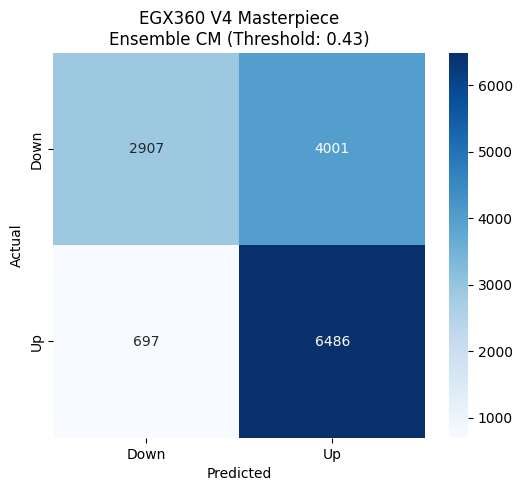

In [3]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pywt  
import xgboost as xgb  # الوحش الجديد
import tensorflow as tf
import tensorflow.keras.backend as K

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, LayerNormalization, 
                                     MultiHeadAttention, GlobalAveragePooling1D, Add)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ==========================================
# 2. DWT Noise Filter (نفس الفلتر الناجح بتاعنا)
# ==========================================
def apply_dwt_denoising(signal):
    signal = np.array(signal, copy=True)
    coeffs = pywt.wavedec(signal, 'db4', level=2)
    coeffs[-1] = np.zeros_like(coeffs[-1])
    denoised = pywt.waverec(coeffs, 'db4')
    return denoised[:len(signal)]

# ==========================================
# 3. Load Data & 4. Feature Engineering
# ==========================================
print("📥 Loading Data & Engineering Features...")
df_daily = pd.read_csv("data/BTC_all_daily.csv")
df_daily['datetime'] = pd.to_datetime(df_daily['datetime'])

df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])

df_fng = pd.read_csv("data/Fear_Greed_Daily.csv") 
df_fng['datetime'] = pd.to_datetime(df_fng['datetime'])

df_daily.sort_values('datetime', inplace=True)
df_hourly.sort_values('datetime', inplace=True)
df_fng.sort_values('datetime', inplace=True)

def calculate_advanced_features(df, prefix):
    df = df.copy()
    df['close_denoised'] = apply_dwt_denoising(df['close'].values)
    df[f'EMA_10_{prefix}'] = df['close_denoised'].ewm(span=10, adjust=False).mean()
    
    delta = df['close_denoised'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'RSI_{prefix}'] = 100 - (100 / (1 + (gain / loss)))
    
    exp12 = df['close_denoised'].ewm(span=12, adjust=False).mean()
    exp26 = df['close_denoised'].ewm(span=26, adjust=False).mean()
    df[f'MACD_{prefix}'] = exp12 - exp26
    
    ma20 = df['close_denoised'].rolling(window=20).mean()
    std20 = df['close_denoised'].rolling(window=20).std()
    df[f'BB_Width_{prefix}'] = (std20 * 4) / ma20
    
    df[f'close_ret_{prefix}'] = df['close'].pct_change()
    df[f'volume_ret_{prefix}'] = df['volume'].pct_change()
    return df.dropna()

df_daily = calculate_advanced_features(df_daily, "daily")
df_hourly = calculate_advanced_features(df_hourly, "hourly")

daily_cols = ['datetime', 'RSI_daily', 'MACD_daily', 'BB_Width_daily', 'close_ret_daily']
df_daily = df_daily[daily_cols]

# ==========================================
# 5. Data Fusion & 6. Scaling
# ==========================================
print("🔗 Performing Triple Fusion...")
df_merged = pd.merge_asof(df_hourly, df_daily, on='datetime', direction='backward')
df_merged = pd.merge_asof(df_merged, df_fng, on='datetime', direction='backward')

df_merged['Target'] = (df_merged['close'].shift(-24) > df_merged['close']).astype(int)
df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)
df_merged.dropna(inplace=True)

final_features = [
    'close_ret_hourly', 'volume_ret_hourly', 'EMA_10_hourly', 'RSI_hourly', 'MACD_hourly', 'BB_Width_hourly', 
    'close_ret_daily', 'RSI_daily', 'MACD_daily', 'BB_Width_daily', 'Fear_Greed_Index'  
]

X_data = df_merged[final_features].values
y_data = df_merged['Target'].values

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)
joblib.dump(scaler, "egx360_scaler_v4.pkl")

split_idx = int(len(X_scaled) * 0.8)
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]

# ==========================================
# 7. Create Sequences (For DL) & Flattening (For XGBoost)
# ==========================================
def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 72 
X_train_dl, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test_dl, y_test = create_sequences(test_data, test_target, SEQ_LEN)

# XGBoost بيحتاج داتا مسطحة (2D) بدل (3D)، فهنضرب 72 ساعة في 11 ميزة
X_train_xgb = X_train_dl.reshape((X_train_dl.shape[0], -1))
X_test_xgb = X_test_dl.reshape((X_test_dl.shape[0], -1))

print(f"📦 DL Shape: {X_train_dl.shape} | XGBoost Shape: {X_train_xgb.shape}")

# ==========================================
# 8. Model A: Time-Series Transformer
# ==========================================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Self-Attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    res = Add()([x, inputs])
    x = LayerNormalization(epsilon=1e-6)(res)
    # Feed Forward
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    res = Add()([x, res])
    return LayerNormalization(epsilon=1e-6)(res)

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.3)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs)

print("\n🧠 Training Model A: Time-Series Transformer...")
transformer_model = build_transformer((X_train_dl.shape[1], X_train_dl.shape[2]))
transformer_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.00001)

transformer_model.fit(
    X_train_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=100, batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
transformer_model.save("EGX360_Transformer.keras")

# ==========================================
# 9. Model B: XGBoost Classifier
# ==========================================
print("\n🌲 Training Model B: XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=50
)
joblib.dump(xgb_model, "EGX360_XGBoost.pkl")

# ==========================================
# 10. Ensemble Learning (Soft Voting)
# ==========================================
print("\n🤝 Performing Ensemble (Transformer + XGBoost)...")
# استخراج الاحتمالات من الموديلين
dl_probs = transformer_model.predict(X_test_dl).flatten()
xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]

# حساب المتوسط (Soft Voting)
final_probs = (dl_probs + xgb_probs) / 2.0

# البحث عن أفضل Threshold ديناميكياً بناءً على الـ Ensemble
thresholds = np.arange(0.1, 0.9, 0.01)
scores = [f1_score(y_test, (final_probs > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(scores)]
print(f'✅ Optimal Ensemble Threshold found: {best_threshold:.2f}')

final_preds = (final_probs > best_threshold).astype(int)

# ==========================================
# 11. Final Evaluation
# ==========================================
print("\n🔥 Final Classification Report (Ensemble V4):")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 V4 Masterpiece\nEnsemble CM (Threshold: {best_threshold:.2f})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

📥 Loading Data Sources (Hourly, Daily, Sentiment, Macro)...
⚙️ Applying DWT and Engineering features for daily data...
⚙️ Applying DWT and Engineering features for hourly data...
🔗 Performing Quad-Fusion (Hourly + Daily + Sentiment + Macro)...
✅ Final Merged Dataset Shape: (70812, 21)
💾 Scaler saved as egx360_scaler_v5.pkl
📦 DL Shape: (56577, 72, 13) | XGBoost Shape: (56577, 936)

🧠 Training Model A: Time-Series Transformer (Macro-Aware)...
Epoch 1/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.5024 - loss: 0.7117 - val_accuracy: 0.5050 - val_loss: 0.6980 - learning_rate: 1.0000e-04
Epoch 2/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.5154 - loss: 0.6947 - val_accuracy: 0.5285 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 3/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.5127 - loss: 0.6940 - val_accuracy: 0.4902 - val_loss: 0.7153 - learning_rate: 1.0000e-04
Epoch 4/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.5

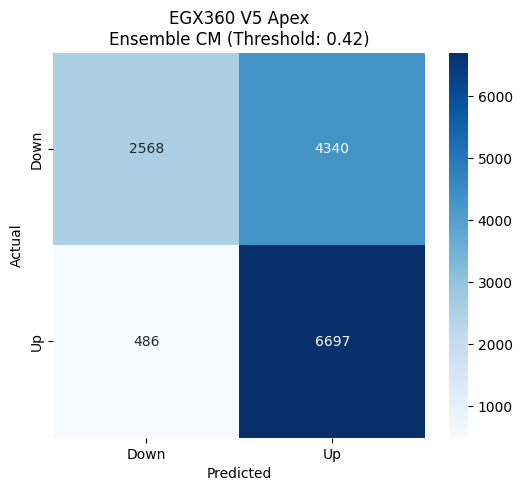

In [5]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pywt  
import xgboost as xgb
import tensorflow as tf
import tensorflow.keras.backend as K

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, LayerNormalization, 
                                     MultiHeadAttention, GlobalAveragePooling1D, Add)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ==========================================
# 2. Advanced Feature: DWT Noise Filter
# ==========================================
def apply_dwt_denoising(signal):
    signal = np.array(signal, copy=True)
    coeffs = pywt.wavedec(signal, 'db4', level=2)
    coeffs[-1] = np.zeros_like(coeffs[-1])
    denoised = pywt.waverec(coeffs, 'db4')
    return denoised[:len(signal)]

# ==========================================
# 3. Load Data Sources (4 Data Streams now!)
# ==========================================
print("📥 Loading Data Sources (Hourly, Daily, Sentiment, Macro)...")

df_daily = pd.read_csv("data/BTC_all_daily.csv")
df_daily['datetime'] = pd.to_datetime(df_daily['datetime'])

df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])

# تأكد إن مسارات الملفات دي صحيحة عندك
df_fng = pd.read_csv("data/Fear_Greed_Daily.csv") 
df_fng['datetime'] = pd.to_datetime(df_fng['datetime'])

df_macro = pd.read_csv("data/Macro_Data_Daily.csv") 
df_macro['datetime'] = pd.to_datetime(df_macro['datetime'])

# ترتيب زمني إجباري
df_daily.sort_values('datetime', inplace=True)
df_hourly.sort_values('datetime', inplace=True)
df_fng.sort_values('datetime', inplace=True)
df_macro.sort_values('datetime', inplace=True)

# حساب العوائد للاقتصاد الكلي
df_macro['SP500_ret'] = df_macro['SP500'].pct_change()
df_macro['DXY_ret'] = df_macro['DXY'].pct_change()
df_macro.dropna(inplace=True)

# ==========================================
# 4. Apply DWT & Feature Engineering
# ==========================================
def calculate_advanced_features(df, prefix):
    print(f"⚙️ Applying DWT and Engineering features for {prefix} data...")
    df = df.copy()
    
    df['close_denoised'] = apply_dwt_denoising(df['close'].values)
    df[f'EMA_10_{prefix}'] = df['close_denoised'].ewm(span=10, adjust=False).mean()
    
    delta = df['close_denoised'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'RSI_{prefix}'] = 100 - (100 / (1 + (gain / loss)))
    
    exp12 = df['close_denoised'].ewm(span=12, adjust=False).mean()
    exp26 = df['close_denoised'].ewm(span=26, adjust=False).mean()
    df[f'MACD_{prefix}'] = exp12 - exp26
    
    ma20 = df['close_denoised'].rolling(window=20).mean()
    std20 = df['close_denoised'].rolling(window=20).std()
    df[f'BB_Width_{prefix}'] = (std20 * 4) / ma20
    
    df[f'close_ret_{prefix}'] = df['close'].pct_change()
    df[f'volume_ret_{prefix}'] = df['volume'].pct_change()
    
    return df.dropna()

df_daily = calculate_advanced_features(df_daily, "daily")
df_hourly = calculate_advanced_features(df_hourly, "hourly")

daily_cols = ['datetime', 'RSI_daily', 'MACD_daily', 'BB_Width_daily', 'close_ret_daily']
df_daily = df_daily[daily_cols]

# ==========================================
# 5. Data Fusion (The Ultimate Quad-Merge)
# ==========================================
print("🔗 Performing Quad-Fusion (Hourly + Daily + Sentiment + Macro)...")

df_merged = pd.merge_asof(df_hourly, df_daily, on='datetime', direction='backward')
df_merged = pd.merge_asof(df_merged, df_fng, on='datetime', direction='backward')
df_merged = pd.merge_asof(df_merged, df_macro[['datetime', 'SP500_ret', 'DXY_ret']], on='datetime', direction='backward')

# Target
df_merged['Target'] = (df_merged['close'].shift(-24) > df_merged['close']).astype(int)

df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)
df_merged.dropna(inplace=True)

final_features = [
    'close_ret_hourly', 'volume_ret_hourly', 'EMA_10_hourly', 'RSI_hourly', 'MACD_hourly', 'BB_Width_hourly', 
    'close_ret_daily', 'RSI_daily', 'MACD_daily', 'BB_Width_daily',
    'Fear_Greed_Index', 
    'SP500_ret', 'DXY_ret'  # الميزات الاقتصادية الجديدة
]

print(f"✅ Final Merged Dataset Shape: {df_merged.shape}")

# ==========================================
# 6. Data Scaling & Splits
# ==========================================
X_data = df_merged[final_features].values
y_data = df_merged['Target'].values

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)
joblib.dump(scaler, "egx360_scaler_v5.pkl")
print("💾 Scaler saved as egx360_scaler_v5.pkl")

split_idx = int(len(X_scaled) * 0.8)
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]

# ==========================================
# 7. Create Sequences (DL) & Flattening (XGBoost)
# ==========================================
def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 72 
X_train_dl, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test_dl, y_test = create_sequences(test_data, test_target, SEQ_LEN)

X_train_xgb = X_train_dl.reshape((X_train_dl.shape[0], -1))
X_test_xgb = X_test_dl.reshape((X_test_dl.shape[0], -1))

print(f"📦 DL Shape: {X_train_dl.shape} | XGBoost Shape: {X_train_xgb.shape}")

# ==========================================
# 8. Model A: Time-Series Transformer
# ==========================================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    res = Add()([x, inputs])
    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    res = Add()([x, res])
    return LayerNormalization(epsilon=1e-6)(res)

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.3)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs)

print("\n🧠 Training Model A: Time-Series Transformer (Macro-Aware)...")
transformer_model = build_transformer((X_train_dl.shape[1], X_train_dl.shape[2]))
transformer_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: weights[i] for i in range(len(weights))}

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.00001)

transformer_model.fit(
    X_train_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=100, batch_size=32,
    class_weight=cw_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
transformer_model.save("EGX360_Transformer_V5.keras")

# ==========================================
# 9. Model B: XGBoost Classifier
# ==========================================
print("\n🌲 Training Model B: XGBoost (Macro-Aware)...")
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=50
)
joblib.dump(xgb_model, "EGX360_XGBoost_V5.pkl")

# ==========================================
# 10. Ensemble Learning (Soft Voting)
# ==========================================
print("\n🤝 Performing Quad-Ensemble V5...")
dl_probs = transformer_model.predict(X_test_dl).flatten()
xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]

final_probs = (dl_probs + xgb_probs) / 2.0

thresholds = np.arange(0.1, 0.9, 0.01)
scores = [f1_score(y_test, (final_probs > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(scores)]
print(f'✅ Optimal V5 Threshold found: {best_threshold:.2f}')

final_preds = (final_probs > best_threshold).astype(int)

# ==========================================
# 11. Final Evaluation
# ==========================================
print("\n🔥 Final Classification Report (The Apex V5):")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 V5 Apex\nEnsemble CM (Threshold: {best_threshold:.2f})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

📥 Loading Data Sources (Hourly, Daily, Sentiment, Macro)...
⚙️ Applying DWT and Engineering features for daily data...
⚙️ Applying DWT and Engineering features for hourly data...
🔗 Performing Quad-Fusion (Hourly + Daily + Sentiment + Macro)...
✅ Final Merged Dataset Shape: (70812, 21)
💾 Scaler saved as egx360_scaler_v6.pkl
📦 DL Shape: (56577, 72, 13) | XGBoost Shape: (56577, 936)

🧠 Training Model A: Time-Series Transformer...
Epoch 1/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.5012 - loss: 0.7066 - val_accuracy: 0.4995 - val_loss: 0.6976 - learning_rate: 1.0000e-04
Epoch 2/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.5135 - loss: 0.6945 - val_accuracy: 0.4978 - val_loss: 0.7012 - learning_rate: 1.0000e-04
Epoch 3/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.5207 - loss: 0.6919 - val_accuracy: 0.4945 - val_loss: 0.7037 - learning_rate: 1.0000e-04
Epoch 4/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.5172 - loss: 0.

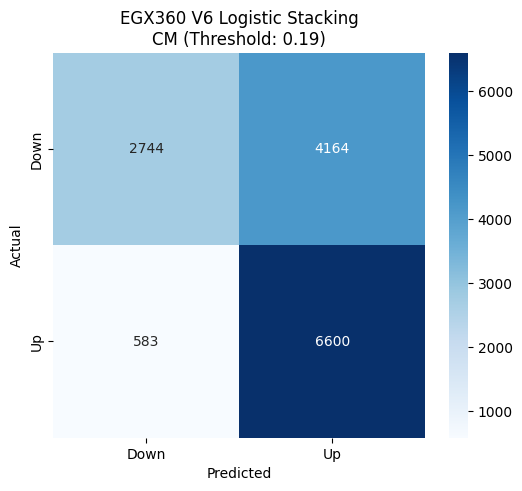

In [7]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pywt  
import xgboost as xgb
import tensorflow as tf
import tensorflow.keras.backend as K

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight
from sklearn.linear_model import LogisticRegression  # 🔥 نجم هذه النسخة

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, LayerNormalization, 
                                     MultiHeadAttention, GlobalAveragePooling1D, Add)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ==========================================
# 2. Advanced Feature: DWT Noise Filter
# ==========================================
def apply_dwt_denoising(signal):
    """فلترة الضوضاء لفصل التريند الحقيقي"""
    signal = np.array(signal, copy=True)
    coeffs = pywt.wavedec(signal, 'db4', level=2)
    coeffs[-1] = np.zeros_like(coeffs[-1])
    denoised = pywt.waverec(coeffs, 'db4')
    return denoised[:len(signal)]

# ==========================================
# 3. Load Data Sources (Quad-Stream)
# ==========================================
print("📥 Loading Data Sources (Hourly, Daily, Sentiment, Macro)...")

df_daily = pd.read_csv("data/BTC_all_daily.csv")
df_daily['datetime'] = pd.to_datetime(df_daily['datetime'])

df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])

df_fng = pd.read_csv("data/Fear_Greed_Daily.csv") 
df_fng['datetime'] = pd.to_datetime(df_fng['datetime'])

df_macro = pd.read_csv("data/Macro_Data_Daily.csv") 
df_macro['datetime'] = pd.to_datetime(df_macro['datetime'])

# ترتيب زمني إجباري
df_daily.sort_values('datetime', inplace=True)
df_hourly.sort_values('datetime', inplace=True)
df_fng.sort_values('datetime', inplace=True)
df_macro.sort_values('datetime', inplace=True)

# حساب العوائد للاقتصاد الكلي
df_macro['SP500_ret'] = df_macro['SP500'].pct_change()
df_macro['DXY_ret'] = df_macro['DXY'].pct_change()
df_macro.dropna(inplace=True)

# ==========================================
# 4. Apply DWT & Feature Engineering
# ==========================================
def calculate_advanced_features(df, prefix):
    print(f"⚙️ Applying DWT and Engineering features for {prefix} data...")
    df = df.copy()
    
    df['close_denoised'] = apply_dwt_denoising(df['close'].values)
    df[f'EMA_10_{prefix}'] = df['close_denoised'].ewm(span=10, adjust=False).mean()
    
    delta = df['close_denoised'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'RSI_{prefix}'] = 100 - (100 / (1 + (gain / loss)))
    
    exp12 = df['close_denoised'].ewm(span=12, adjust=False).mean()
    exp26 = df['close_denoised'].ewm(span=26, adjust=False).mean()
    df[f'MACD_{prefix}'] = exp12 - exp26
    
    ma20 = df['close_denoised'].rolling(window=20).mean()
    std20 = df['close_denoised'].rolling(window=20).std()
    df[f'BB_Width_{prefix}'] = (std20 * 4) / ma20
    
    df[f'close_ret_{prefix}'] = df['close'].pct_change()
    df[f'volume_ret_{prefix}'] = df['volume'].pct_change()
    
    return df.dropna()

df_daily = calculate_advanced_features(df_daily, "daily")
df_hourly = calculate_advanced_features(df_hourly, "hourly")

daily_cols = ['datetime', 'RSI_daily', 'MACD_daily', 'BB_Width_daily', 'close_ret_daily']
df_daily = df_daily[daily_cols]

# ==========================================
# 5. Data Fusion (Quad-Merge)
# ==========================================
print("🔗 Performing Quad-Fusion (Hourly + Daily + Sentiment + Macro)...")

df_merged = pd.merge_asof(df_hourly, df_daily, on='datetime', direction='backward')
df_merged = pd.merge_asof(df_merged, df_fng, on='datetime', direction='backward')
df_merged = pd.merge_asof(df_merged, df_macro[['datetime', 'SP500_ret', 'DXY_ret']], on='datetime', direction='backward')

# Target
df_merged['Target'] = (df_merged['close'].shift(-24) > df_merged['close']).astype(int)

df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)
df_merged.dropna(inplace=True)

final_features = [
    'close_ret_hourly', 'volume_ret_hourly', 'EMA_10_hourly', 'RSI_hourly', 'MACD_hourly', 'BB_Width_hourly', 
    'close_ret_daily', 'RSI_daily', 'MACD_daily', 'BB_Width_daily',
    'Fear_Greed_Index', 
    'SP500_ret', 'DXY_ret' 
]

print(f"✅ Final Merged Dataset Shape: {df_merged.shape}")

# ==========================================
# 6. Data Scaling & Splits
# ==========================================
X_data = df_merged[final_features].values
y_data = df_merged['Target'].values

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)
joblib.dump(scaler, "egx360_scaler_v6.pkl")
print("💾 Scaler saved as egx360_scaler_v6.pkl")

split_idx = int(len(X_scaled) * 0.8)
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]

# ==========================================
# 7. Create Sequences (DL) & Flattening (XGBoost)
# ==========================================
def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 72 
X_train_dl, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test_dl, y_test = create_sequences(test_data, test_target, SEQ_LEN)

X_train_xgb = X_train_dl.reshape((X_train_dl.shape[0], -1))
X_test_xgb = X_test_dl.reshape((X_test_dl.shape[0], -1))

print(f"📦 DL Shape: {X_train_dl.shape} | XGBoost Shape: {X_train_xgb.shape}")

# ==========================================
# 8. Model A: Time-Series Transformer
# ==========================================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    res = Add()([x, inputs])
    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    res = Add()([x, res])
    return LayerNormalization(epsilon=1e-6)(res)

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.3)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs)

print("\n🧠 Training Model A: Time-Series Transformer...")
transformer_model = build_transformer((X_train_dl.shape[1], X_train_dl.shape[2]))
transformer_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: weights[i] for i in range(len(weights))}

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.00001)

transformer_model.fit(
    X_train_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=100, batch_size=32,
    class_weight=cw_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
transformer_model.save("EGX360_Transformer_V6.keras")

# ==========================================
# 9. Model B: XGBoost Classifier
# ==========================================
print("\n🌲 Training Model B: XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=50
)
joblib.dump(xgb_model, "EGX360_XGBoost_V6.pkl")

# ==========================================
# 10. The Ultimate Ensemble: Stacking with Logistic Regression
# ==========================================
print("\n🔥 Training Meta-Learner (Logistic Regression Stacking)...")

# استخراج توقعات التدريب لتعليم المدير
print("   -> Gathering predictions on Training Data...")
dl_train_probs = transformer_model.predict(X_train_dl, batch_size=64).flatten()
xgb_train_probs = xgb_model.predict_proba(X_train_xgb)[:, 1]

# دمج التوقعات
meta_X_train = np.column_stack((dl_train_probs, xgb_train_probs))

# تدريب مدير الموديلات (Logistic Regression)
print("   -> Fitting the Logistic Regression Meta-Learner...")
meta_model = LogisticRegression()
meta_model.fit(meta_X_train, y_train)

# استخراج توقعات الاختبار
print("   -> Gathering predictions on Testing Data...")
dl_test_probs = transformer_model.predict(X_test_dl, batch_size=64).flatten()
xgb_test_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]

# دمج توقعات الاختبار
meta_X_test = np.column_stack((dl_test_probs, xgb_test_probs))

# القرار النهائي من المدير
print("🤝 Meta-Learner is making the final decisions...")
final_probs = meta_model.predict_proba(meta_X_test)[:, 1]

# البحث عن أفضل Threshold ديناميكياً
thresholds = np.arange(0.1, 0.9, 0.01)
scores = [f1_score(y_test, (final_probs > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(scores)]
print(f'✅ Optimal Stacking Threshold found: {best_threshold:.2f}')

final_preds = (final_probs > best_threshold).astype(int)

# حفظ مدير الموديلات
joblib.dump(meta_model, "EGX360_Meta_Logistic_V6.pkl")
print("💾 Meta-Learner saved as EGX360_Meta_Logistic_V6.pkl")

# ==========================================
# 11. Final Evaluation
# ==========================================
print("\n🏆 Final Classification Report (V6 - Logistic Stacking):")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 V6 Logistic Stacking\nCM (Threshold: {best_threshold:.2f})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# ============================================================
#   EGX360 V7 — BTC DIRECTION PREDICTOR (FULL CLEAN REWRITE)
#   Architecture: HMM Regime → CNN-BiLSTM-Attention + LightGBM → Stacking
#   Keras 3 fully compatible — zero tf.* ops outside layers
# ============================================================

# ==========================================
# 1. Libraries
# ==========================================
# pip install hmmlearn lightgbm shap optuna pywavelets tensorflow scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pywt
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from hmmlearn.hmm import GaussianHMM

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout,
    Bidirectional, LSTM, Conv1D, MaxPooling1D,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("✅ All libraries loaded.")
print(f"   TensorFlow : {tf.__version__}")
print(f"   Keras      : {tf.keras.__version__}")


# ==========================================
# 2. Keras 3 Safe Custom Layers
#    (no tf.* ops in symbolic graph — only keras.ops.*)
# ==========================================

class AddPositionalEncoding(tf.keras.layers.Layer):
    """
    Sinusoidal positional encoding stored as a non-trainable weight.
    Safe for Keras 3 functional API.
    """
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        positions = np.arange(seq_len)[:, np.newaxis].astype(np.float32)
        dims      = np.arange(d_model)[np.newaxis,  :].astype(np.float32)
        angles    = positions / np.power(10000.0, (2.0 * (dims // 2)) / d_model)
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        self.pe = self.add_weight(
            name="pos_enc",
            shape=(1, seq_len, d_model),
            initializer=tf.keras.initializers.Constant(angles[np.newaxis]),
            trainable=False,
        )

    def call(self, inputs):
        return inputs + self.pe

    def get_config(self):
        return super().get_config()


class TemporalAttention(tf.keras.layers.Layer):
    """
    Soft temporal attention: (batch, T, F) -> (batch, F).
    Uses keras.ops.sum — works with all Keras 3 backends.
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.score_dense = Dense(1, activation="tanh", use_bias=True)
        self.softmax     = tf.keras.layers.Softmax(axis=1)

    def call(self, inputs):
        score   = self.score_dense(inputs)        # (batch, T, 1)
        score   = self.softmax(score)             # (batch, T, 1)
        context = inputs * score                  # (batch, T, F)
        return tf.keras.ops.sum(context, axis=1)  # (batch, F)

    def get_config(self):
        return super().get_config()


# ==========================================
# 3. DWT Noise Filter
# ==========================================
def apply_dwt_denoising(signal):
    signal   = np.array(signal, copy=True)
    coeffs   = pywt.wavedec(signal, 'db4', level=2)
    coeffs[-1] = np.zeros_like(coeffs[-1])
    denoised = pywt.waverec(coeffs, 'db4')
    return denoised[:len(signal)]


# ==========================================
# 4. Load Data
# ==========================================
print("\n📥 Loading Data Sources...")

df_daily  = pd.read_csv("data/BTC_all_daily.csv")
df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_fng    = pd.read_csv("data/Fear_Greed_Daily.csv")
df_macro  = pd.read_csv("data/Macro_Data_Daily.csv")

for df in [df_daily, df_hourly, df_fng, df_macro]:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.sort_values('datetime', inplace=True)

df_macro['SP500_ret'] = df_macro['SP500'].pct_change()
df_macro['DXY_ret']   = df_macro['DXY'].pct_change()
df_macro.dropna(inplace=True)


# ==========================================
# 5. Feature Engineering
# ==========================================
def calculate_advanced_features(df, prefix):
    print(f"⚙️  Engineering features [{prefix}]...")
    df = df.copy()

    df['close_denoised'] = apply_dwt_denoising(df['close'].values)
    cd = df['close_denoised']

    # Trend
    df[f'EMA_10_{prefix}']  = cd.ewm(span=10,  adjust=False).mean()
    df[f'EMA_21_{prefix}']  = cd.ewm(span=21,  adjust=False).mean()
    df[f'EMA_50_{prefix}']  = cd.ewm(span=50,  adjust=False).mean()
    df[f'SMA_200_{prefix}'] = cd.rolling(200).mean()

    # RSI
    delta = cd.diff()
    gain  = delta.where(delta > 0, 0).rolling(14).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
    df[f'RSI_{prefix}'] = 100 - (100 / (1 + gain / (loss + 1e-9)))

    # Stochastic RSI
    rsi     = df[f'RSI_{prefix}']
    rsi_min = rsi.rolling(14).min()
    rsi_max = rsi.rolling(14).max()
    df[f'StochRSI_{prefix}'] = (rsi - rsi_min) / (rsi_max - rsi_min + 1e-9)

    # MACD
    exp12 = cd.ewm(span=12, adjust=False).mean()
    exp26 = cd.ewm(span=26, adjust=False).mean()
    df[f'MACD_{prefix}']        = exp12 - exp26
    df[f'MACD_signal_{prefix}'] = df[f'MACD_{prefix}'].ewm(span=9, adjust=False).mean()
    df[f'MACD_hist_{prefix}']   = df[f'MACD_{prefix}'] - df[f'MACD_signal_{prefix}']

    # Bollinger Bands
    ma20  = cd.rolling(20).mean()
    std20 = cd.rolling(20).std()
    df[f'BB_Width_{prefix}'] = (std20 * 4) / (ma20 + 1e-9)
    df[f'BB_Pos_{prefix}']   = (cd - (ma20 - 2*std20)) / (4*std20 + 1e-9)

    # ATR
    if 'high' in df.columns and 'low' in df.columns:
        df[f'ATR_{prefix}'] = (df['high'] - df['low']).rolling(14).mean()
    else:
        df[f'ATR_{prefix}'] = std20 * 1.5

    # Volume
    df[f'OBV_{prefix}']          = (np.sign(df['close'].diff()) * df['volume']).cumsum()
    df[f'VWAP_{prefix}']         = (df['close'] * df['volume']).rolling(24).sum() / \
                                    (df['volume'].rolling(24).sum() + 1e-9)
    df[f'volume_ratio_{prefix}'] = df['volume'] / (df['volume'].rolling(20).mean() + 1e-9)

    # Returns
    df[f'close_ret_{prefix}']  = df['close'].pct_change()
    df[f'close_ret2_{prefix}'] = df['close'].pct_change(2)
    df[f'close_ret6_{prefix}'] = df['close'].pct_change(6)
    df[f'volume_ret_{prefix}'] = df['volume'].pct_change()

    # Candle position
    if 'high' in df.columns and 'low' in df.columns:
        df[f'high_low_ratio_{prefix}'] = (df['close'] - df['low']) / \
                                          (df['high'] - df['low'] + 1e-9)
    else:
        df[f'high_low_ratio_{prefix}'] = 0.5

    return df.dropna()


df_daily  = calculate_advanced_features(df_daily,  "daily")
df_hourly = calculate_advanced_features(df_hourly, "hourly")

daily_cols = [
    'datetime',
    'RSI_daily', 'StochRSI_daily', 'MACD_daily', 'MACD_hist_daily',
    'BB_Width_daily', 'BB_Pos_daily', 'ATR_daily',
    'close_ret_daily', 'EMA_10_daily', 'EMA_50_daily',
]
df_daily = df_daily[daily_cols]


# ==========================================
# 6. HMM Market Regime Detection
# ==========================================
print("\n🔮 Fitting HMM (Bull / Sideways / Bear)...")

daily_full = pd.read_csv("data/BTC_all_daily.csv")
daily_full['datetime'] = pd.to_datetime(daily_full['datetime'])
daily_full.sort_values('datetime', inplace=True)
daily_full['ret']     = daily_full['close'].pct_change()
daily_full['log_ret'] = np.log(daily_full['close'] / daily_full['close'].shift(1))
daily_full.dropna(inplace=True)

hmm_scaler = RobustScaler()
hmm_scaled = hmm_scaler.fit_transform(daily_full[['log_ret', 'ret']].values)

hmm_model = GaussianHMM(n_components=3, covariance_type="full",
                         n_iter=200, random_state=42)
hmm_model.fit(hmm_scaled)

# Map raw states → 0=Bear 1=Sideways 2=Bull by mean log-return
means         = [hmm_model.means_[i][0] for i in range(3)]
sorted_states = np.argsort(means)
state_map     = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}
raw_regimes   = hmm_model.predict(hmm_scaled)

daily_full['regime'] = [state_map[s] for s in raw_regimes]
regime_map           = daily_full[['datetime', 'regime']].copy()
print(f"   Distribution → {daily_full['regime'].value_counts().to_dict()}")

joblib.dump(hmm_model,  "EGX360_HMM_V7.pkl")
joblib.dump(hmm_scaler, "EGX360_HMM_Scaler_V7.pkl")


# ==========================================
# 7. Data Fusion
# ==========================================
print("\n🔗 Quad-Fusion: Hourly + Daily + FnG + Macro + Regime...")

df_merged = pd.merge_asof(df_hourly, df_daily, on='datetime', direction='backward')
df_merged = pd.merge_asof(df_merged, df_fng,   on='datetime', direction='backward')
df_merged = pd.merge_asof(df_merged,
                           df_macro[['datetime', 'SP500_ret', 'DXY_ret']],
                           on='datetime', direction='backward')
df_merged = pd.merge_asof(df_merged, regime_map, on='datetime', direction='backward')

df_merged['regime_bull']     = (df_merged['regime'] == 2).astype(int)
df_merged['regime_sideways'] = (df_merged['regime'] == 1).astype(int)
df_merged['regime_bear']     = (df_merged['regime'] == 0).astype(int)


# ==========================================
# 8. Volatility-Adjusted Target
# ==========================================
atr_14     = df_merged['close'].rolling(14).apply(lambda x: x.max() - x.min(), raw=True)
future_ret = df_merged['close'].shift(-24) - df_merged['close']
threshold  = 0.4 * atr_14

df_merged['Target'] = np.where(future_ret >  threshold,  1,
                      np.where(future_ret < -threshold,  0, np.nan))

df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)
df_merged.dropna(subset=['Target'], inplace=True)
df_merged['Target'] = df_merged['Target'].astype(int)

print(f"\n✅ After ATR-filter : {len(df_merged):,} rows | "
      f"Up={df_merged['Target'].sum():,} | "
      f"Down={(df_merged['Target']==0).sum():,}")


# ==========================================
# 9. Final Feature Set
# ==========================================
candidate_features = [
    'close_ret_hourly', 'close_ret2_hourly', 'close_ret6_hourly',
    'volume_ret_hourly', 'volume_ratio_hourly',
    'EMA_10_hourly', 'RSI_hourly', 'StochRSI_hourly',
    'MACD_hourly', 'MACD_hist_hourly',
    'BB_Width_hourly', 'BB_Pos_hourly',
    'ATR_hourly', 'OBV_hourly', 'VWAP_hourly',
    'high_low_ratio_hourly',
    'close_ret_daily', 'RSI_daily', 'MACD_hist_daily',
    'BB_Width_daily', 'ATR_daily', 'EMA_50_daily',
    'Fear_Greed_Index', 'SP500_ret', 'DXY_ret',
    'regime_bull', 'regime_sideways', 'regime_bear',
]

final_features = [f for f in candidate_features if f in df_merged.columns]
print(f"📊 Using {len(final_features)} features: {final_features}")

X_data = df_merged[final_features].values
y_data = df_merged['Target'].values


# ==========================================
# 10. Scaling & Train / Test Split
# ==========================================
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X_data)
joblib.dump(scaler, "egx360_scaler_v7.pkl")
print("💾 Scaler saved → egx360_scaler_v7.pkl")

split_idx    = int(len(X_scaled) * 0.8)
train_data   = X_scaled[:split_idx]
test_data    = X_scaled[split_idx:]
train_target = y_data[:split_idx]
test_target  = y_data[split_idx:]


# ==========================================
# 11. Sequence Creation  (SEQ_LEN = 72 h)
# ==========================================
SEQ_LEN = 72

def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : i + seq_len])
        ys.append(target[i + seq_len])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.int32)

X_train_dl,  y_train = create_sequences(train_data,  train_target, SEQ_LEN)
X_test_dl,   y_test  = create_sequences(test_data,   test_target,  SEQ_LEN)

X_train_lgb = X_train_dl.reshape(len(X_train_dl), -1)
X_test_lgb  = X_test_dl.reshape(len(X_test_dl),  -1)

print(f"\n📦 DL  shape : {X_train_dl.shape}")
print(f"📦 LGB shape : {X_train_lgb.shape}")


# ==========================================
# 12. MODEL A — CNN-BiLSTM-Attention
# ==========================================
def build_cnn_bilstm_attention(input_shape):
    seq_len, n_feat = input_shape
    inputs = Input(shape=input_shape, name="sequence_input")

    x = AddPositionalEncoding(seq_len, n_feat, name="pos_enc")(inputs)

    x = Conv1D(64,  kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(64,  kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(128, return_sequences=True,
                            dropout=0.2, recurrent_dropout=0.1))(x)
    x = Bidirectional(LSTM(64,  return_sequences=True,
                            dropout=0.2, recurrent_dropout=0.1))(x)

    x = TemporalAttention(name="attention")(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64,  activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs, name="CNN_BiLSTM_Attention")


print("\n🧠 Building CNN-BiLSTM-Attention...")
cnn_bilstm_model = build_cnn_bilstm_attention(
    (X_train_dl.shape[1], X_train_dl.shape[2])
)
cnn_bilstm_model.summary()

cw_arr  = class_weight.compute_class_weight('balanced',
                                             classes=np.unique(y_train),
                                             y=y_train)
cw_dict = {i: cw_arr[i] for i in range(len(cw_arr))}

cnn_bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

dl_callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
]

print("\n🧠 Training Model A...")
history = cnn_bilstm_model.fit(
    X_train_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=100,
    batch_size=64,
    class_weight=cw_dict,
    callbacks=dl_callbacks,
    verbose=1,
)
cnn_bilstm_model.save("EGX360_CNN_BiLSTM_Attn_V7.keras")
print("💾 Saved → EGX360_CNN_BiLSTM_Attn_V7.keras")


# ==========================================
# 13. MODEL B — LightGBM + Optuna HPO
# ==========================================
print("\n🌲 Tuning LightGBM with Optuna (30 trials)...")

def lgb_objective(trial):
    params = {
        'objective':         'binary',
        'metric':            'binary_logloss',
        'verbosity':         -1,
        'boosting_type':     trial.suggest_categorical('boosting', ['gbdt', 'dart']),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.05),
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state':      42,
    }
    tscv   = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr_idx, va_idx in tscv.split(X_train_lgb):
        clf = lgb.LGBMClassifier(**params)
        clf.fit(
            X_train_lgb[tr_idx], y_train[tr_idx],
            eval_set=[(X_train_lgb[va_idx], y_train[va_idx])],
            callbacks=[lgb.early_stopping(30, verbose=False),
                       lgb.log_evaluation(-1)],
        )
        scores.append(f1_score(y_train[va_idx], clf.predict(X_train_lgb[va_idx])))
    return float(np.mean(scores))

study = optuna.create_study(direction='maximize')
study.optimize(lgb_objective, n_trials=30, show_progress_bar=True)
print(f"\n   Best params : {study.best_params}")
print(f"   Best F1     : {study.best_value:.4f}")

best_params = study.best_params
best_params.update({'objective': 'binary', 'metric': 'binary_logloss',
                    'verbosity': -1, 'random_state': 42})

lgb_model = lgb.LGBMClassifier(**best_params)
lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=True),
               lgb.log_evaluation(100)],
)
joblib.dump(lgb_model, "EGX360_LightGBM_V7.pkl")
print("💾 Saved → EGX360_LightGBM_V7.pkl")


# ==========================================
# 14. SHAP Feature Importance
# ==========================================
print("\n📊 Computing SHAP values...")
explainer       = shap.TreeExplainer(lgb_model)
shap_sample     = X_test_lgb[:500]
shap_vals       = explainer.shap_values(shap_sample)
shap_importance = np.abs(shap_vals).mean(axis=0)

feat_names_flat = [f"{f}_t{t}" for t in range(SEQ_LEN) for f in final_features]
top_idx   = np.argsort(shap_importance)[-20:][::-1]
top_names = [feat_names_flat[i] if i < len(feat_names_flat) else f"feat_{i}"
             for i in top_idx]

plt.figure(figsize=(10, 6))
sns.barh(top_names[::-1], shap_importance[top_idx][::-1], color='steelblue')
plt.title("V7 — Top 20 Features (SHAP)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig("shap_importance_v7.png", dpi=150)
plt.show()
print("💾 Saved → shap_importance_v7.png")


# ==========================================
# 15. Regime-Aware Stacking
# ==========================================
print("\n🔥 Building Regime-Aware Stacking Ensemble...")

print("   Predicting train set...")
dl_train_probs  = cnn_bilstm_model.predict(X_train_dl, batch_size=128, verbose=0).flatten()
lgb_train_probs = lgb_model.predict_proba(X_train_lgb)[:, 1]

print("   Predicting test set...")
dl_test_probs  = cnn_bilstm_model.predict(X_test_dl, batch_size=128, verbose=0).flatten()
lgb_test_probs = lgb_model.predict_proba(X_test_lgb)[:, 1]

# Align regime labels
train_regime_idx = np.clip(np.arange(SEQ_LEN, SEQ_LEN + len(y_train)),
                           0, len(df_merged) - 1)
train_regimes    = df_merged['regime'].values[train_regime_idx]

test_start       = split_idx + SEQ_LEN
test_end         = min(test_start + len(y_test), len(df_merged))
test_regimes     = df_merged['regime'].values[test_start:test_end]
if len(test_regimes) < len(y_test):
    test_regimes = np.pad(test_regimes, (0, len(y_test) - len(test_regimes)))

def build_meta_X(dl_p, lgb_p, regs):
    n = min(len(dl_p), len(lgb_p), len(regs))
    return np.column_stack([
        dl_p[:n], lgb_p[:n],
        (regs[:n] == 2).astype(float),
        (regs[:n] == 1).astype(float),
        (regs[:n] == 0).astype(float),
    ])

meta_X_train = build_meta_X(dl_train_probs, lgb_train_probs, train_regimes)
meta_X_test  = build_meta_X(dl_test_probs,  lgb_test_probs,  test_regimes)

n_train = meta_X_train.shape[0]
n_test  = meta_X_test.shape[0]
y_tr    = y_train[:n_train]
y_te    = y_test[:n_test]

meta_model = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
meta_model.fit(meta_X_train, y_tr)
joblib.dump(meta_model, "EGX360_Meta_V7.pkl")
print("💾 Saved → EGX360_Meta_V7.pkl")


# ==========================================
# 16. Dynamic Threshold
# ==========================================
final_probs    = meta_model.predict_proba(meta_X_test)[:, 1]
thresholds     = np.arange(0.25, 0.75, 0.01)
f1_scores_arr  = [f1_score(y_te, (final_probs > t).astype(int)) for t in thresholds]
best_threshold = float(thresholds[np.argmax(f1_scores_arr)])
print(f"\n✅ Optimal threshold : {best_threshold:.2f}  |  Best F1 : {max(f1_scores_arr):.4f}")

final_preds = (final_probs > best_threshold).astype(int)


# ==========================================
# 17. Final Evaluation
# ==========================================
print("\n" + "="*60)
print("🏆  EGX360 V7 — FINAL RESULTS")
print("="*60)

acc = (final_preds == y_te).mean()
auc = roc_auc_score(y_te, final_probs)
f1  = f1_score(y_te, final_preds)

print(f"\n  Accuracy : {acc*100:.2f}%")
print(f"  AUC-ROC  : {auc:.4f}")
print(f"  F1-Score : {f1:.4f}\n")
print(classification_report(y_te, final_preds, target_names=['Down', 'Up']))

dl_solo  = (dl_test_probs[:n_test]  > 0.5).astype(int)
lgb_solo = (lgb_test_probs[:n_test] > 0.5).astype(int)
print(f"  CNN-BiLSTM alone : {(dl_solo  == y_te).mean()*100:.2f}%")
print(f"  LightGBM   alone : {(lgb_solo == y_te).mean()*100:.2f}%")
print(f"  ENSEMBLE   V7    : {acc*100:.2f}%  ← final")


# ==========================================
# 18. Plots
# ==========================================
# Confusion matrix
cm = confusion_matrix(y_te, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 V7  Acc={acc*100:.1f}%  AUC={auc:.3f}  Thr={best_threshold:.2f}")
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("confusion_matrix_v7.png", dpi=150)
plt.show()

# Training history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.suptitle("CNN-BiLSTM-Attention Training", fontsize=13)
plt.tight_layout()
plt.savefig("training_history_v7.png", dpi=150)
plt.show()

print("💾 Plots saved → confusion_matrix_v7.png | training_history_v7.png")


# ==========================================
# 19. Files Summary
# ==========================================
print("\n📦 Saved files:")
for f in [
    "EGX360_CNN_BiLSTM_Attn_V7.keras",
    "EGX360_LightGBM_V7.pkl",
    "EGX360_HMM_V7.pkl",
    "EGX360_HMM_Scaler_V7.pkl",
    "EGX360_Meta_V7.pkl",
    "egx360_scaler_v7.pkl",
    "shap_importance_v7.png",
    "confusion_matrix_v7.png",
    "training_history_v7.png",
]:
    print(f"   {f}")

print(f"\n🎯 EGX360 V7 → {acc*100:.2f}% accuracy on held-out test set.")


# ==========================================
# 20. Live Inference
# ==========================================
def predict_next_24h(df_72h):
    """
    Predict BTC direction 24 h ahead.

    Parameters
    ----------
    df_72h : pd.DataFrame
        Last 72 hourly rows with engineered features matching final_features.

    Returns
    -------
    dict  {signal, confidence, regime, dl_prob, lgb_prob}
    """
    _sc   = joblib.load("egx360_scaler_v7.pkl")
    _dl   = tf.keras.models.load_model(
                "EGX360_CNN_BiLSTM_Attn_V7.keras",
                custom_objects={
                    "AddPositionalEncoding": AddPositionalEncoding,
                    "TemporalAttention":     TemporalAttention,
                },
            )
    _lgbm = joblib.load("EGX360_LightGBM_V7.pkl")
    _meta = joblib.load("EGX360_Meta_V7.pkl")
    _hmm  = joblib.load("EGX360_HMM_V7.pkl")
    _hsc  = joblib.load("EGX360_HMM_Scaler_V7.pkl")

    close  = df_72h['close'].values
    ret    = (close[-1] - close[-2]) / (close[-2] + 1e-9)
    log_r  = np.log(close[-1] / (close[-2] + 1e-9))
    regime = int(_hmm.predict(_hsc.transform([[log_r, ret]]))[0])

    X       = df_72h[final_features].values
    X_sc    = _sc.transform(X)
    dl_p    = float(_dl.predict(X_sc[np.newaxis].astype(np.float32), verbose=0)[0][0])
    lgb_p   = float(_lgbm.predict_proba(X_sc.reshape(1, -1))[0][1])

    meta_in    = np.array([[dl_p, lgb_p,
                             float(regime == 2),
                             float(regime == 1),
                             float(regime == 0)]])
    final_prob = float(_meta.predict_proba(meta_in)[0][1])

    signal = 'UP 📈' if final_prob > best_threshold else 'DOWN 📉'
    names  = {0: 'Bear 🐻', 1: 'Sideways ↔️', 2: 'Bull 🐂'}

    return {
        'signal':     signal,
        'confidence': f"{final_prob*100:.1f}%",
        'regime':     names.get(regime, '?'),
        'dl_prob':    f"{dl_p*100:.1f}%",
        'lgb_prob':   f"{lgb_p*100:.1f}%",
    }


print("\n✅ Done! Call predict_next_24h(df_72h) for live inference.")

2026-03-07 00:46:56.823630: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-07 00:46:56.823985: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 00:46:56.869786: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-07 00:46:58.719241: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

✅ All libraries loaded.
   TensorFlow : 2.20.0
   Keras      : 3.13.2

📥 Loading Data Sources...
⚙️  Engineering features [daily]...
⚙️  Engineering features [hourly]...

🔮 Fitting HMM (Bull / Sideways / Bear)...
   Distribution → {1: 2598, 2: 893, 0: 697}

🔗 Quad-Fusion: Hourly + Daily + FnG + Macro + Regime...

✅ After ATR-filter : 50,571 rows | Up=26,471 | Down=24,100
📊 Using 28 features: ['close_ret_hourly', 'close_ret2_hourly', 'close_ret6_hourly', 'volume_ret_hourly', 'volume_ratio_hourly', 'EMA_10_hourly', 'RSI_hourly', 'StochRSI_hourly', 'MACD_hourly', 'MACD_hist_hourly', 'BB_Width_hourly', 'BB_Pos_hourly', 'ATR_hourly', 'OBV_hourly', 'VWAP_hourly', 'high_low_ratio_hourly', 'close_ret_daily', 'RSI_daily', 'MACD_hist_daily', 'BB_Width_daily', 'ATR_daily', 'EMA_50_daily', 'Fear_Greed_Index', 'SP500_ret', 'DXY_ret', 'regime_bull', 'regime_sideways', 'regime_bear']
💾 Scaler saved → egx360_scaler_v7.pkl

📦 DL  shape : (40384, 72, 28)
📦 LGB shape : (40384, 2016)

🧠 Building CNN-BiLST

E0000 00:00:1772837220.541888   50345 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772837220.558627   50345 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 72, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_enc (AddPositionalEncoding) │ (None, 72, 28)         │         2,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 72, 64)         │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 72, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 36, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 36, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 18, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 18, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (TemporalAttention)   │ (None, 128)            │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 496,994 (1.90 MB)

 Trainable params: 494,978 (1.89 MB)

 Non-trainable params: 2,016 (7.88 KB)


🧠 Training Model A...
Epoch 1/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 55s 75ms/step - accuracy: 0.4792 - loss: 0.6932 - val_accuracy: 0.4882 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 2/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.5070 - loss: 0.6931 - val_accuracy: 0.5118 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 3/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.5253 - loss: 0.6931 - val_accuracy: 0.4882 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 4/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 46s 72ms/step - accuracy: 0.4765 - loss: 0.6932 - val_accuracy: 0.4882 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 5/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.4945 - loss: 0.6932 - val_accuracy: 0.4882 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 6/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.4843 - loss: 0.6931 - val_accuracy: 0.4882 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 7/100
631/631 ━━━

  0%|          | 0/30 [00:00<?, ?it/s]